In [1]:
import os
os.environ['USE_PYGEOS'] = '0'

import sys
from pathlib import Path
import geopandas as gpd

parent_dir = Path().resolve().parent
sys.path.insert(0, str(parent_dir))
from map2grid import *

import re

In [2]:
# Import generators
gens_gdf = gpd.read_file('../data/osm/plant.gpkg')

# Import substations from table_nodes_500m.gpkg
nodes_gdf = gpd.read_file('../outputs/table_nodes_500m.gpkg')

# Import installed capacity of genertors with different energy sources in 2023
df = pd.read_csv('../data/yearly_full_release_long_format.csv')
installed_capacity_df = df[
    (df["Area"] == "Viet Nam") &
    (df["Year"] == 2023) &
    (df["Category"] == "Capacity") &
    (df["Subcategory"] == "Fuel")
]

installed_capacity_df['Value_MW'] = installed_capacity_df['Value'] * 1000

# df = pd.read_csv('../data/yearly_full_release_long_format.csv')
electricity_generation_df = df[
    (df["Area"] == "Viet Nam") &
    (df["Year"] == 2023) &
    (df["Category"] == "Electricity generation") &
    (df["Subcategory"] == "Fuel") &
    (df["Unit"] == "TWh")
]

electricity_generation_df['Value_GWh'] = electricity_generation_df['Value'] * 1000

/tmp/ipykernel_2222265/574364912.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  installed_capacity_df['Value_MW'] = installed_capacity_df['Value'] * 1000
/tmp/ipykernel_2222265/574364912.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  electricity_generation_df['Value_GWh'] = electricity_generation_df['Value'] * 1000


In [3]:
sum(electricity_generation_df['Value_GWh'])

276440.0

In [4]:
electricity_generation_df

,Area,Country code,Year,Area type,Continent,Ember region,EU,OECD,G20,G7,ASEAN,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change,Value_GWh
335128,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Bioenergy,TWh,0.85,0.47,123.68,850.0
335129,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Coal,TWh,129.58,25.54,24.55,129580.0
335130,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Gas,TWh,26.32,-2.90,-9.92,26320.0
335131,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Hydro,TWh,80.90,-15.01,-15.65,80900.0
335132,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Nuclear,TWh,0.00,0.00,NaN,0.0
335133,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Other Fossil,TWh,1.72,1.00,138.89,1720.0
335134,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Solar,TWh,25.70,-0.05,-0.19,25700.0
335135,Viet Nam,VNM,2023,Country,Asia,Asia,0.0,0.0,0.0,0.0,1.0,Electricity generation,Fuel,Wind,TWh,11.37,2.28,25.08,11370.0


In [5]:
# 步骤 1：新增 installed_capacity 列
def convert_to_mw(value):
    if pd.isnull(value):
        return None
    
    # 使用正则表达式提取数字部分（包括小数）
    match = re.search(r"([\d.]+)", value)
    if not match:
        raise ValueError(f"Unexpected value: {value}")
    
    number = float(match.group(1))  # 提取匹配到的数字部分
    
    # 根据单位进行转换
    if "MW" in value or "MWp" in value:
        return number
    elif "kW" in value:
        return number / 1000  # kW 转换为 MW
    elif "GW" in value:
        return number * 1000  # GW 转换为 MW
    else:
        raise ValueError(f"Unexpected value: {value}")


In [6]:
installed_capacity = []
for i, row in gens_gdf.iterrows():
    try:
        if pd.notnull(row["plant_output_electricity"]):
            installed_capacity.append(convert_to_mw(row["plant_output_electricity"]))
        elif pd.notnull(row["generator_output_electricity"]):
            installed_capacity.append(convert_to_mw(row["generator_output_electricity"]))
        else:
            installed_capacity.append(None)
    except ValueError as e:
        print("osm_id ", row['osm_id'], ": ", e, " ")
        installed_capacity.append(None)

gens_gdf["installed_capacity"] = installed_capacity

osm_id  1927484927 :  Unexpected value: yes  
osm_id  2495831951 :  Unexpected value: yes  
osm_id  859265181 :  Unexpected value: yes  
osm_id  9445022182 :  Unexpected value: yes  
osm_id  9445022189 :  Unexpected value: yes  
osm_id  9445022190 :  Unexpected value: yes  
osm_id  9445033851 :  Unexpected value: yes  
osm_id  9445033852 :  Unexpected value: yes  
osm_id  9445033853 :  Unexpected value: yes  
osm_id  9445033854 :  Unexpected value: yes  
osm_id  9445033914 :  Unexpected value: yes  
osm_id  9445033915 :  Unexpected value: yes  
osm_id  9445033916 :  Unexpected value: yes  
osm_id  9445033917 :  Unexpected value: yes  
osm_id  9445033918 :  Unexpected value: yes  
osm_id  9742040890 :  Unexpected value: yes  
osm_id  9742066679 :  Unexpected value: yes  
osm_id  9742066689 :  Unexpected value: yes  
osm_id  9742066690 :  Unexpected value: yes  
osm_id  9742100904 :  Unexpected value: yes  
osm_id  9742100905 :  Unexpected value: yes  
osm_id  9742100906 :  Unexpected va

In [7]:
# 步骤 2：新增 energy_source 列
gens_gdf["energy_source"] = gens_gdf["plant_source"].combine_first(gens_gdf["generator_source"])

In [8]:
# 步骤 3：统计 energy_source 的唯一值
unique_energy_sources = gens_gdf["energy_source"].dropna().unique()
print("Unique energy sources:", unique_energy_sources)

Unique energy sources: ['hydro' 'coal' 'wind' 'biofuel' 'diesel' 'biogas' 'gas' 'solar'
 'substation' 'gas;oil' 'oil' 'waste']


In [9]:
gas_no_capacity = gens_gdf[(gens_gdf['energy_source'] == 'gas')] # & (gens_gdf['installed_capacity'].isna())]
gas_no_capacity

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,generator_type,substation,location,cables,circuits,line,layer,geometry,installed_capacity,energy_source
45,11322122,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,750 MW,...,combined_cycle,NaN,NaN,NaN,NaN,NaN,NaN,POINT (506733.390 1021088.163),750.0,gas
46,11322122,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,750 MW,...,combined_cycle,NaN,NaN,NaN,NaN,NaN,NaN,POINT (506676.730 1021625.546),750.0,gas
677,16528602,plant,NaN,NaN,Nhà máy Nhiệt điện Phú Mỹ,NaN,3975 MW,gas,combustion,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((722370.903 1173264.156, 722335...",3975.0,gas
686,400202736,plant,NaN,NaN,Nhà máy Nhiệt điện Nhơn Trạch,NaN,1200 MW,gas,combustion,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((701406.459 1177383.321, 701424...",1200.0,gas


In [10]:
# 1. 按 'energy_source' 分组统计行数
energy_source_counts = gens_gdf.groupby("energy_source").size()

# 2. 按 'energy_source' 和 'installed_capacity' 是否为 NaN 分组，计算行数
installed_capacity_counts = gens_gdf.groupby(["energy_source", ~gens_gdf["installed_capacity"].isna()]).size()

# 3. 对于有 'installed_capacity' 的行，统计其总和和平均值
installed_capacity_stats = gens_gdf[gens_gdf["installed_capacity"].notna()].groupby("energy_source")["installed_capacity"].agg(['sum', 'mean'])

# 输出结果
print("Energy source counts (total rows per energy source):")
print(energy_source_counts)

print("\nInstalled capacity counts (rows with and without installed capacity per energy source):")
print(installed_capacity_counts)

print("\nInstalled capacity statistics (sum and mean for rows with installed capacity):")
print(installed_capacity_stats)


Energy source counts (total rows per energy source):
energy_source
biofuel         1
biogas          1
coal           24
diesel          2
gas             4
gas;oil         1
hydro         165
oil             2
solar         302
substation      3
waste           1
wind          646
dtype: int64

Installed capacity counts (rows with and without installed capacity per energy source):
energy_source  installed_capacity
biofuel        False                   1
biogas         False                   1
coal           False                  13
               True                   11
diesel         False                   2
gas            True                    4
gas;oil        True                    1
hydro          False                 103
               True                   62
oil            False                   2
solar          False                 292
               True                   10
substation     False                   3
waste          False                   1
wind   

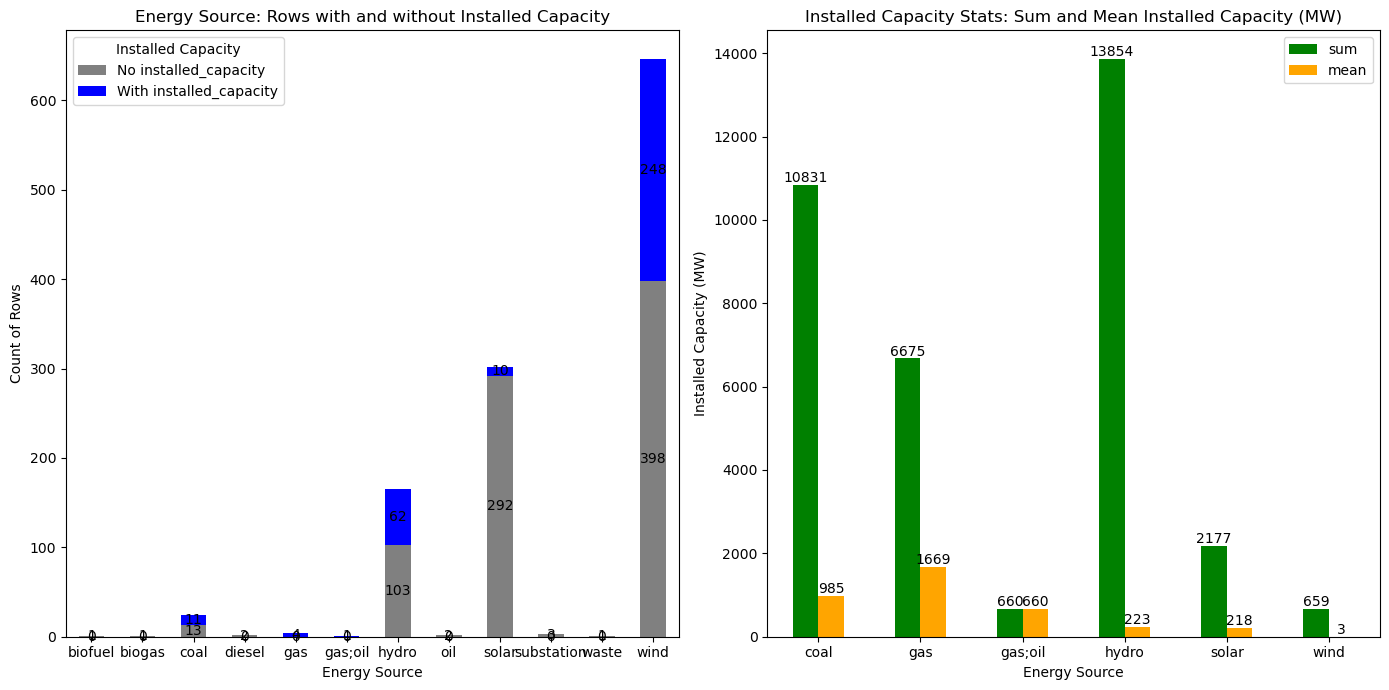

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 展示每个 energy_source 的总行数和有无 installed_capacity 的行数
fig, ax = plt.subplots(1, 2, figsize=(14, 7))

# (a) 堆叠柱状图：显示每个 energy_source 中有和没有 installed_capacity 的行数
installed_capacity_counts_unstacked = installed_capacity_counts.unstack().fillna(0)
installed_capacity_counts_unstacked.columns = ['No installed_capacity', 'With installed_capacity']
installed_capacity_counts_unstacked.plot(kind='bar', stacked=True, ax=ax[0], color=['gray', 'blue'])
ax[0].set_title('Energy Source: Rows with and without Installed Capacity')
ax[0].set_ylabel('Count of Rows')
ax[0].set_xlabel('Energy Source')
ax[0].legend(title='Installed Capacity')

# 在每个堆叠柱子的中间添加数字
for p in ax[0].patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2.  # 获取柱子的 x 位置
    y = p.get_y() + height / 2.  # 获取每部分柱子的中心位置 (y是堆叠的起点)

    ax[0].annotate(f'{height:.0f}', (x, y), ha='center', va='center', fontsize=10, color='black') #, fontweight='bold'

# (b) 对每个 energy_source 显示 installed_capacity 的总和和平均值
installed_capacity_stats.plot(kind='bar', ax=ax[1], color=['green', 'orange'])
ax[1].set_title('Installed Capacity Stats: Sum and Mean Installed Capacity (MW)')
ax[1].set_ylabel('Installed Capacity (MW)')
ax[1].set_xlabel('Energy Source')

# 在每个柱子上添加数字
for p in ax[1].patches:
    height = p.get_height()
    x = p.get_x() + p.get_width() / 2.  # 获取柱子的 x 位置
    y = height  # 每个柱子的中心位置 (y是柱子的起点)

    ax[1].annotate(f'{height:.0f}', (x, y), ha='center', va='center', fontsize=10, color='black', xytext=(0, 5), textcoords='offset points') #, fontweight='bold'

ax[0].tick_params(axis='x', rotation=0)
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


In [12]:
gens_gdf[gens_gdf["energy_source"].isin(["diesel"])]

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,generator_type,substation,location,cables,circuits,line,layer,geometry,installed_capacity,energy_source
25,5237495186,generator,NaN,NaN,Cây Xăng Tỉnh Ủy,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (516754.200 1014248.500),NaN,diesel
26,5246574100,generator,NaN,NaN,Trạm cấp xăng An Bình - CA.TPCT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (586035.283 1106693.670),NaN,diesel


In [13]:
# Step 4: 对 filtered_gdf 的 energy_source 进行对应
# 创建一个映射字典，将 energy_source 映射到对应的 INSTALLED CAPACITY (MW)
energy_source_mapping = {
    "hydro": "Hydro",
    "coal": "Coal",
    # "oil": "Other Fossil",
    # "diesel": "Other Fossil",
    "oil": "Gas",
    "diesel": "Gas",
    "gas": "Gas",
    "gas;oil": "Gas",
    "waste": "Bioenergy",
    "biofuel": "Bioenergy", 
    "biogas": "Bioenergy",
    "wind": "Wind",
    "solar": "Solar"
}

# 根据 energy_source 列来映射到 energy_source_stats 列
gens_gdf["energy_source"] = gens_gdf["energy_source"].map(energy_source_mapping)

In [14]:
# 步骤 5：拆分 GeoDataFrame
condition_1 = gens_gdf["installed_capacity"].notnull() & gens_gdf["energy_source"].notnull()
condition_2 = gens_gdf["installed_capacity"].isnull() & gens_gdf["energy_source"].notnull()
condition_3 = gens_gdf["installed_capacity"].notnull() & gens_gdf["energy_source"].isnull()
condition_4 = gens_gdf["installed_capacity"].isnull() & gens_gdf["energy_source"].isnull()

gdf_1 = gens_gdf[condition_1]
gdf_2 = gens_gdf[condition_2]
gdf_3 = gens_gdf[condition_3]
gdf_4 = gens_gdf[condition_4]

print(f"GeoDataFrame 1 (not null installed_capacity and energy_source): {len(gdf_1)} rows")
print(f"GeoDataFrame 2 (null installed_capacity, not null energy_source): {len(gdf_2)} rows")
print(f"GeoDataFrame 3 (not null installed_capacity, null energy_source): {len(gdf_3)} rows")
print(f"GeoDataFrame 4 (null installed_capacity and energy_source): {len(gdf_4)} rows")

GeoDataFrame 1 (not null installed_capacity and energy_source): 336 rows
GeoDataFrame 2 (null installed_capacity, not null energy_source): 813 rows
GeoDataFrame 3 (not null installed_capacity, null energy_source): 0 rows
GeoDataFrame 4 (null installed_capacity and energy_source): 29 rows


In [15]:
# pd.concat([gdf_3, gdf_4])

In [16]:
indices_to_remove = pd.concat([gdf_3, gdf_4]).index
filtered_gdf = gens_gdf.drop(indices_to_remove)

In [17]:
print("Number of original plants/generators: ", len(gens_gdf))
print("Number of filtered plants/generators: ", len(filtered_gdf))
print("Number of removed plants/generators: ", len(indices_to_remove))

Number of original plants/generators:  1178
Number of filtered plants/generators:  1149
Number of removed plants/generators:  29


In [18]:
# df = pd.read_csv('../data/yearly_full_release_long_format.csv')

# # 筛选数据：仅包括 "Viet Nam"、"Capacity"、"Fuel" 分类的数据
# installed_capacity_df = df[
#     (df["Area"] == "Viet Nam") &
#     (df["Category"] == "Capacity") &
#     (df["Subcategory"] == "Fuel")
# ]

# # 选择必要的列
# data = installed_capacity_df[['Year', 'Variable', 'Value', 'YoY % change']]

# # 排除 'Nuclear' 和 'Other Fossil'
# data = data[~data['Variable'].isin(['Nuclear', 'Other Fossil'])]

# # 计算最近几年的年增长率均值，并根据该均值预测2024年值
# def predict_for_variable_using_growth_rate(variable_df):
#     # 过滤掉包含NaN值的行（如果有的话）
#     variable_df = variable_df.dropna(subset=['Value', 'YoY % change'])
    
#     # 如果数据点不足以进行预测，返回NaN
#     if len(variable_df) < 2:
#         return np.nan
    
#     # 计算最近几年的增长率均值（例如最近3年）
#     recent_years = variable_df.tail(3)  # 取最近三年的数据
#     avg_growth_rate = recent_years['YoY % change'].mean()  # 计算均值

#     # 取2023年的Value
#     value_2023 = recent_years.iloc[-1]['Value']

#     # 根据均值增长率预测2024年的值
#     predicted_value_2024 = value_2023 * (1 + avg_growth_rate / 100)
    
#     return predicted_value_2024

# # 获取每种能源类型的预测值
# predictions = []
# for variable in data['Variable'].unique():
#     variable_data = data[data['Variable'] == variable]
#     predicted_value_2024 = predict_for_variable_using_growth_rate(variable_data)
    
#     # 收集预测结果
#     predictions.append({
#         'Variable': variable,
#         'Predicted_Value_2024': predicted_value_2024
#     })

# # 将结果转化为DataFrame
# predictions_df = pd.DataFrame(predictions)

In [19]:
gdf_1 = filtered_gdf[condition_1]
gdf_2 = filtered_gdf[condition_2]

/scistor/ivm/mye500/miniconda3/envs/py310/lib/python3.10/site-packages/geopandas/geodataframe.py:1415: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)
/scistor/ivm/mye500/miniconda3/envs/py310/lib/python3.10/site-packages/geopandas/geodataframe.py:1415: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  result = super().__getitem__(key)


In [20]:
# Step 7: 根据 energy_source_stats 分类计算 gdf_1 中的总值
gdf_1_grouped = gdf_1.groupby("energy_source")["installed_capacity"].sum()


In [21]:
gdf_1_grouped

energy_source
Coal     10831.000
Gas       7335.000
Hydro    13854.258
Solar     2176.752
Wind       658.993
Name: installed_capacity, dtype: float64

In [22]:
# Step 8: 从 energy_source_stats 的 installed_capacity 中减去 gdf_1 的分类总值
remaining_capacity = {}
for _, row in installed_capacity_df.iterrows():
    category = row["Variable"]
    if category in gdf_1_grouped:
        remaining_capacity[category] = row['Value_MW'] - gdf_1_grouped[category]
    else:
        remaining_capacity[category] = row['Value_MW']

In [23]:
remaining_capacity

{'Bioenergy': 380.0,
 'Coal': 16409.0,
 'Gas': 815.0,
 'Hydro': 8785.742,
 'Nuclear': nan,
 'Other Fossil': nan,
 'Solar': 14903.248,
 'Wind': 5231.007}

In [24]:
# Step 9: 计算 gdf_2 中每个 energy_source 的 installed_capacity 总和, 将剩余容量按比例分配到 gdf_2
def allocate_remaining_capacity(row, remaining_capacity, gdf_2_counts):
    stats = row["energy_source"]
    if stats in remaining_capacity and stats in gdf_2_counts:
        return remaining_capacity[stats] / gdf_2_counts[stats]
    return 0  # 如果没有对应的剩余值或分组总和，分配为 0

# 计算 gdf_2 中每类 energy_source 的行数
gdf_2_counts = gdf_2["energy_source"].value_counts()

# 创建一个新列，将剩余容量分配到 gdf_2 的每一行
gdf_2["installed_capacity"] = gdf_2.apply(
    allocate_remaining_capacity, axis=1, 
    remaining_capacity=remaining_capacity, 
    gdf_2_counts=gdf_2_counts
)

gdf_2

/scistor/ivm/mye500/miniconda3/envs/py310/lib/python3.10/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,generator_type,substation,location,cables,circuits,line,layer,geometry,installed_capacity,energy_source
0,1927484927,generator,NaN,NaN,Thủy điện Đray H'Linh,NaN,NaN,NaN,NaN,yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (815417.599 1403022.166),85.298466,Hydro
1,2495831951,generator,NaN,NaN,Nhà máy nhiệt điện HẢi Phòng,NaN,NaN,NaN,NaN,yes,...,francis_turbine,NaN,NaN,NaN,NaN,NaN,NaN,POINT (672042.829 2306269.564),1262.230769,Coal
24,5207569281,generator,NaN,NaN,Trạm biến áp 110/220v,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (584157.030 1108307.081),126.666667,Bioenergy
25,5237495186,generator,NaN,NaN,Cây Xăng Tỉnh Ủy,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (516754.200 1014248.500),203.750000,Gas
26,5246574100,generator,NaN,NaN,Trạm cấp xăng An Bình - CA.TPCT,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (586035.283 1106693.670),203.750000,Gas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1171,16135954,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (719742.558 1311293.226, 719883.515...",51.038521,Solar
1172,16135954,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (720156.912 1310897.281, 720159.327...",51.038521,Solar
1173,16135954,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (720058.471 1311085.961, 720258.182...",51.038521,Solar
1174,16135954,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (720028.393 1311011.909, 720028.317...",51.038521,Solar


In [25]:
# 1. 按 'energy_source' 分组统计行数
energy_source_counts = gdf_2.groupby("energy_source").size()

# 2. 按 'energy_source' 和 'installed_capacity' 是否为 NaN 分组，计算行数
installed_capacity_counts = gdf_2.groupby(["energy_source", gdf_2["installed_capacity"].isna()]).size()

# 3. 对于有 'installed_capacity' 的行，统计其总和和平均值
installed_capacity_stats = gdf_2[gdf_2["installed_capacity"].notna()].groupby("energy_source")["installed_capacity"].agg(['sum', 'mean'])

# 输出结果
print("Energy source counts (total rows per energy source):")
print(energy_source_counts)

print("\nInstalled capacity counts (rows with and without installed capacity per energy source):")
print(installed_capacity_counts)

print("\nInstalled capacity statistics (sum and mean for rows with installed capacity):")
print(installed_capacity_stats)


Energy source counts (total rows per energy source):
energy_source
Bioenergy      3
Coal          13
Gas            4
Hydro        103
Solar        292
Wind         398
dtype: int64

Installed capacity counts (rows with and without installed capacity per energy source):
energy_source  installed_capacity
Bioenergy      False                   3
Coal           False                  13
Gas            False                   4
Hydro          False                 103
Solar          False                 292
Wind           False                 398
dtype: int64

Installed capacity statistics (sum and mean for rows with installed capacity):
                     sum         mean
energy_source                        
Bioenergy        380.000   126.666667
Coal           16409.000  1262.230769
Gas              815.000   203.750000
Hydro           8785.742    85.298466
Solar          14903.248    51.038521
Wind            5231.007    13.143234


In [26]:
gens_gdf_update = pd.concat([gdf_1, gdf_2], ignore_index=True)

In [27]:
gens_gdf_update

,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,generator_type,substation,location,cables,circuits,line,layer,geometry,installed_capacity,energy_source
0,2691123367,plant,NaN,NaN,Nhà máy thủy điện Hòa Bình,NaN,1920 MW,hydro,water-storage,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (533441.720 2301260.380),1920.000000,Hydro
1,4037744488,plant,NaN,NaN,Nhà máy thủy điện Yaly,NaN,720 MW,hydro,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,POINT (801696.934 1574168.128),720.000000,Hydro
2,4195284426,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500 kW,...,horizontal_axis,NaN,NaN,NaN,NaN,NaN,NaN,POINT (902041.116 1240835.743),1.500000,Wind
3,4195284427,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500 kW,...,horizontal_axis,NaN,NaN,NaN,NaN,NaN,NaN,POINT (901941.698 1241043.240),1.500000,Wind
4,4195284428,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500 kW,...,horizontal_axis,NaN,NaN,NaN,NaN,NaN,NaN,POINT (902908.591 1241107.802),1.500000,Wind
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1144,16135954,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (719742.558 1311293.226, 719883.515...",51.038521,Solar
1145,16135954,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (720156.912 1310897.281, 720159.327...",51.038521,Solar
1146,16135954,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (720058.471 1311085.961, 720258.182...",51.038521,Solar
1147,16135954,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"LINESTRING (720028.393 1311011.909, 720028.317...",51.038521,Solar


In [28]:
# 分配electricity production
# Step 1: Calculate Area for each generator
def calculate_area(geometry):
    geometry = linestring_to_polygon(geometry)
    
    if geometry.geom_type in ['Polygon', 'MultiPolygon', 'LineString']:
        return geometry.area
    elif geometry.geom_type == 'Point':
        return 500  # Default area for Point
    else:
        return 0

# Apply the area calculation to each generator
gens_gdf_update['Area'] = gens_gdf_update['geometry'].apply(calculate_area)

# Step 2: Distribute Value_GWh based on Area and energy_source
def distribute_generation(row):
    # Filter electricity_generation_df based on the current generator's energy source
    relevant_generation = electricity_generation_df[electricity_generation_df['Variable'] == row['energy_source']]
    if not relevant_generation.empty:
        total_area = gens_gdf_update.loc[gens_gdf_update['energy_source'] == row['energy_source'], 'Area'].sum()
        proportion = row['Area'] / total_area
        return relevant_generation['Value_GWh'].values[0] * proportion
    else:
        return 0

# Apply the distribution function to each generator
gens_gdf_update['electricity_generation_GWh'] = gens_gdf_update.apply(distribute_generation, axis=1)

gens_gdf_update

/scistor/ivm/mye500/miniconda3/envs/py310/lib/python3.10/site-packages/geopandas/geoseries.py:645: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  result = super().apply(func, convert_dtype=convert_dtype, args=args, **kwargs)


,osm_id,power,voltage,utility,name,frequency,plant_output_electricity,plant_source,plant_method,generator_output_electricity,...,location,cables,circuits,line,layer,geometry,installed_capacity,energy_source,Area,electricity_generation_GWh
0,2691123367,plant,NaN,NaN,Nhà máy thủy điện Hòa Bình,NaN,1920 MW,hydro,water-storage,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (533441.720 2301260.380),1920.000000,Hydro,500.000000,114.048047
1,4037744488,plant,NaN,NaN,Nhà máy thủy điện Yaly,NaN,720 MW,hydro,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,POINT (801696.934 1574168.128),720.000000,Hydro,500.000000,114.048047
2,4195284426,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500 kW,...,NaN,NaN,NaN,NaN,NaN,POINT (902041.116 1240835.743),1.500000,Wind,500.000000,14.660159
3,4195284427,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500 kW,...,NaN,NaN,NaN,NaN,NaN,POINT (901941.698 1241043.240),1.500000,Wind,500.000000,14.660159
4,4195284428,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1500 kW,...,NaN,NaN,NaN,NaN,NaN,POINT (902908.591 1241107.802),1.500000,Wind,500.000000,14.660159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1144,16135954,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,"LINESTRING (719742.558 1311293.226, 719883.515...",51.038521,Solar,9734.044029,2.488067
1145,16135954,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,"LINESTRING (720156.912 1310897.281, 720159.327...",51.038521,Solar,31523.366211,8.057519
1146,16135954,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,"LINESTRING (720058.471 1311085.961, 720258.182...",51.038521,Solar,28232.283605,7.216303
1147,16135954,generator,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,"LINESTRING (720028.393 1311011.909, 720028.317...",51.038521,Solar,5139.121732,1.313583


In [29]:
sum(gens_gdf_update['electricity_generation_GWh'])

274719.99999999633

In [30]:
distance_threshold = 580000  # 580 km

for idx, generator in gens_gdf_update.iterrows():
    distances = nodes_gdf.geometry.distance(generator.geometry)

    # 找到最近的 node，并确保其距离在阈值范围内
    nearest_idx = distances.idxmin()  # 找到距离最小的索引
    nearest_distance = distances.loc[nearest_idx]

    if nearest_distance <= distance_threshold:
        nearest_node_id = nodes_gdf.at[nearest_idx, 'Index']
        # 将最近节点的 NodeID 分配给 generator 的 BusID
        gens_gdf_update.at[idx, 'BusID'] = nearest_node_id

    else:
        # 如果没有满足条件的节点，设置 BusID 为 None 或其他默认值
        gens_gdf_update.at[idx, 'BusID'] = None

# 检查是否有 BusID 为 None 的行
none_busid_count = gens_gdf_update['BusID'].isna().sum()
print(f"Number of generators with BusID as None: {none_busid_count}")

Number of generators with BusID as None: 0


In [31]:
# distance_threshold = 580000  # 580 km

# # Only consider substations in nodes_gdf with NodeID (osmid)> 6 digits.
# subs_gdf = nodes_gdf[nodes_gdf['NodeID'].astype(str).str.len() > 6]

# for idx, generator in gens_gdf_update.iterrows():
#     distances = subs_gdf.geometry.distance(generator.geometry)

#     # 找到最近的 node，并确保其距离在阈值范围内
#     nearest_idx = distances.idxmin()  # 找到距离最小的索引
#     nearest_distance = distances.loc[nearest_idx]

#     if nearest_distance <= distance_threshold:
#         nearest_node_id = subs_gdf.at[nearest_idx, 'NodeID']
#         # 将最近节点的 NodeID 分配给 generator 的 BusID
#         gens_gdf_update.at[idx, 'BusID'] = nearest_node_id

#     else:
#         # 如果没有满足条件的节点，设置 BusID 为 None 或其他默认值
#         gens_gdf_update.at[idx, 'BusID'] = None

# # 检查是否有 BusID 为 None 的行
# none_busid_count = gens_gdf_update['BusID'].isna().sum()
# print(f"Number of generators with BusID as None: {none_busid_count}")

In [32]:
gens_gdf_update.to_file("../data/osm/plant_update.gpkg", driver="GPKG", crs='EPSG:32648')
gens_gdf_update.to_excel("../data/osm/plant_update.xlsx", index=False)